In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.



  NVDA: 2513 rows
  SPY: 2513 rows
  CBA.AX: 2530 rows
  BHP.AX: 2530 rows
  7203.T: 2463 rows
  6758.T: 2463 rows

  MEAN REVERSION STRATEGY — FULL COMPARISON TABLE
                        B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
Ticker MR Params                                                                                                                                           
6758.T MR(w=10, z=1.0)              505.81                102.35                   7.48        0.65          0.37        -39.78          -31.59       50.89
       MR(w=10, z=1.5)              505.81                158.90                  10.23        0.65          0.57        -39.78          -29.04       52.71
       MR(w=10, z=2.0)              505.81                 71.00                   5.64        0.65          0.39        -39.78          -28.04       53.19
       MR(w=10, z=2.5)              505.81           

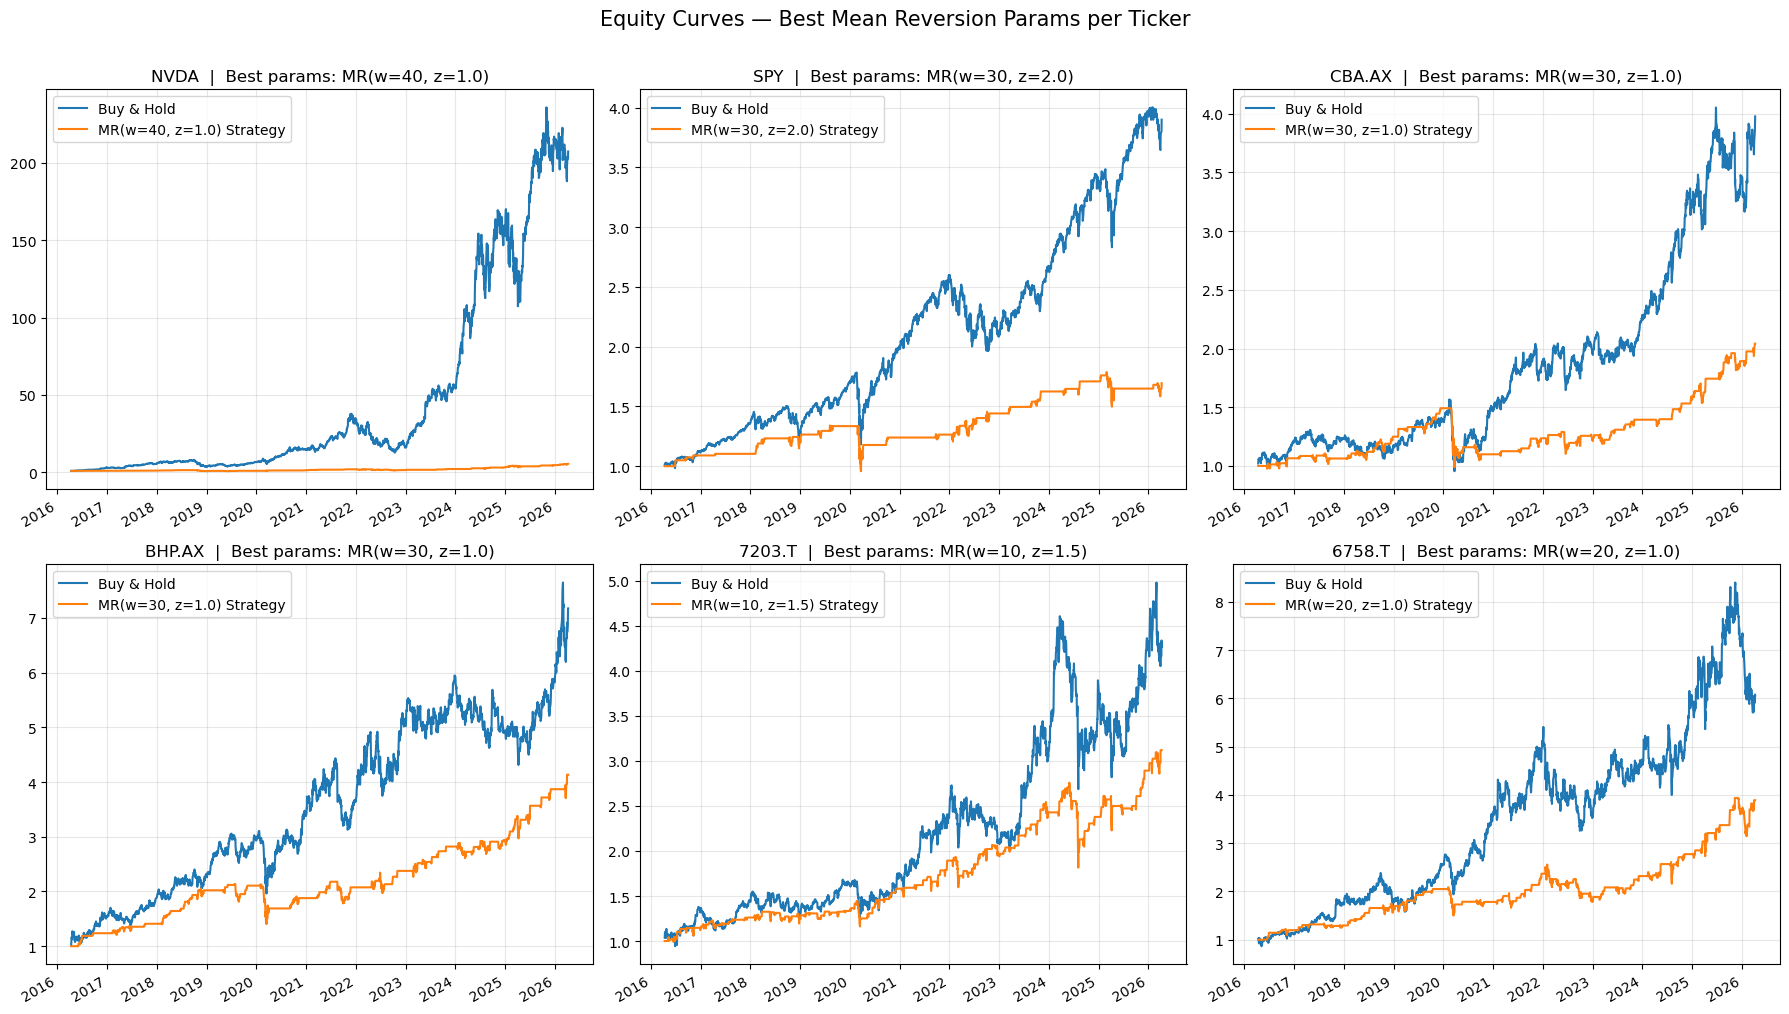


Chart saved as mr_best_equity_curves.png


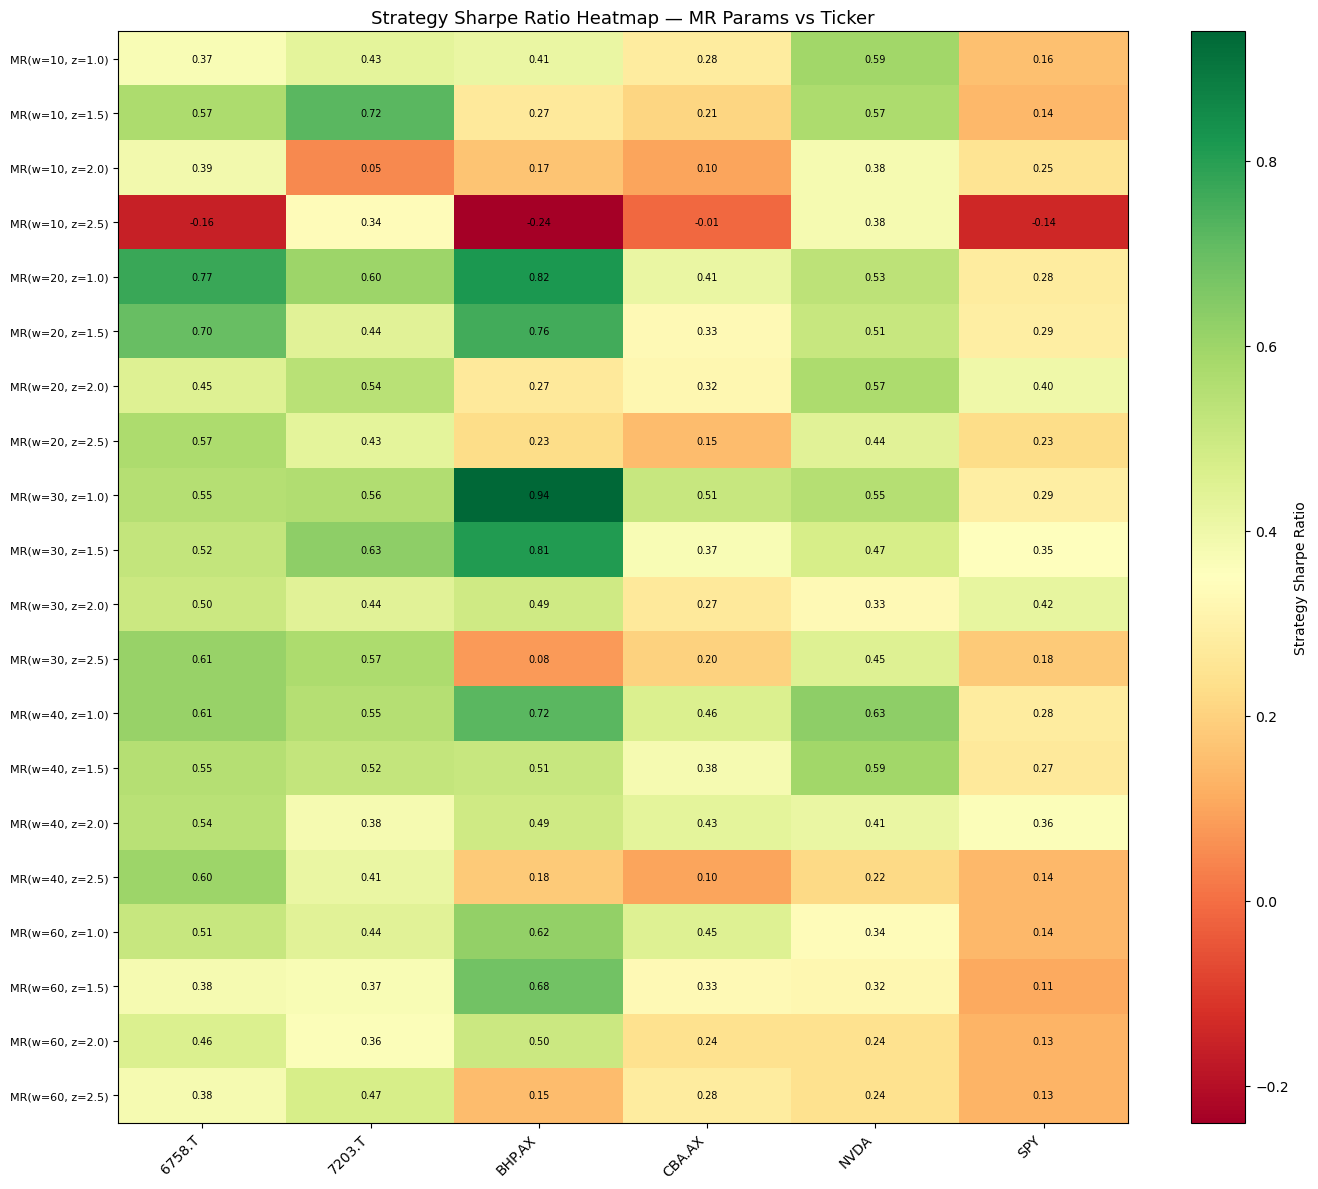

Heatmap saved as mr_sharpe_heatmap.png


In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

# ── Configuration ──────────────────────────────────────────────────────────────
endDate   = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365 * 10)

stocks = ["NVDA", "SPY", "CBA.AX", "BHP.AX", "7203.T", "6758.T"]

# Mean Reversion parameter combos to test: (window, threshold)
# window    = how many days of history we use to compute the mean and std dev
#             shorter = reacts faster to recent price moves (noisier)
#             longer  = smoother average (slower to signal)
# threshold = how many std deviations away from mean before we act
#             lower threshold (e.g. 1.0) = more frequent trades, noisier signals
#             higher threshold (e.g. 2.5) = fewer trades, only on big dislocations
#
# Example: window=20, threshold=1.5 means:
#   - compute the 20-day rolling mean and std of price
#   - if today's price is 1.5 std devs BELOW that mean → buy (expect reversion up)
#   - exit when price reverts back above the mean (Z-score > 0)
windows    = [10, 20, 30, 40, 60]
thresholds = [1.0, 1.5, 2.0, 2.5]
mr_params  = [(w, t) for w in windows for t in thresholds]

# 252 trading days/year
PERIODS_PER_YEAR = 252


# ── Helper: compute Z-score ────────────────────────────────────────────────────
# Z-score tells us how far the current price is from its recent average
# measured in units of standard deviations.
#
# Z = (Price - Rolling Mean) / Rolling Std Dev
#
# Z = 0   → price is exactly at its average (no signal)
# Z = -2  → price is 2 std devs BELOW average → cheap → buy signal
# Z = +2  → price is 2 std devs ABOVE average → expensive → exit/short signal
#
# This is a STATISTICAL strategy — it doesn't care about the direction of the
# trend, only about how far the price has deviated from its recent normal.
# It assumes prices will always drift back toward their mean — which works
# well for range-bound stocks (e.g. utilities, commodities) but FAILS for
# strong momentum stocks like NVDA which trend for extended periods.
def compute_zscore(price_series, window):
    rolling_mean = price_series.rolling(window=window).mean()
    rolling_std  = price_series.rolling(window=window).std()
    zscore       = (price_series - rolling_mean) / rolling_std
    return zscore


# ── Helper: run a single Mean Reversion backtest ───────────────────────────────
# Logic: pure statistical mean reversion (long-only)
#   BUY  when Z-score drops below -threshold
#        → price is unusually far below its recent mean → expect reversion UP
#   EXIT when Z-score rises back above 0
#        → price has returned to its average → take profit, reset
#
# We do NOT short (i.e. we don't sell when Z > +threshold).
# Long-only is safer and more realistic for individual investors.
#
# Key difference from MA/RSI/MACD: those strategies FOLLOW trends.
# Mean Reversion BETS AGAINST trends — it profits from temporary dips,
# not from sustained moves. This makes it the opposite philosophy to MACD.
def run_backtest(price_series, window, threshold):
    df = pd.DataFrame({"price": price_series})
    df["zscore"] = compute_zscore(df["price"], window)

    # Raw signal:
    #   1 = we are IN the trade (bought because Z < -threshold, haven't exited yet)
    #   0 = we are OUT (either haven't triggered yet, or Z reverted above 0)
    signal = np.zeros(len(df))
    in_trade = False
    for i in range(len(df)):
        z = df["zscore"].iloc[i]
        if np.isnan(z):
            signal[i] = 0
        elif not in_trade and z < -threshold:
            in_trade   = True   # enter: Z crossed below -threshold
            signal[i]  = 1
        elif in_trade and z >= 0:
            in_trade   = False  # exit: Z reverted back above 0 (mean reached)
            signal[i]  = 0
        else:
            signal[i]  = 1 if in_trade else 0

    df["signal_raw"] = signal
    df["position"]   = df["signal_raw"].shift(1)  # act the day AFTER signal fires

    df["log_returns"]          = np.log(df["price"] / df["price"].shift(1))
    df["strategy_log_returns"] = df["position"] * df["log_returns"]

    df["cum_market"]   = np.exp(df["log_returns"].cumsum())
    df["cum_strategy"] = np.exp(df["strategy_log_returns"].cumsum())
    return df


# ── Helper: max drawdown ───────────────────────────────────────────────────────
def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    drawdown    = (cum_series - running_max) / running_max
    return drawdown.min()


# ── Helper: compute all metrics for one backtest run ──────────────────────────
def get_metrics(df):
    market_lr   = df["log_returns"].dropna()
    strategy_lr = df["strategy_log_returns"].dropna()

    total_mkt   = df["cum_market"].dropna().iloc[-1]   - 1
    total_strat = df["cum_strategy"].dropna().iloc[-1] - 1

    ann_mkt     = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat   = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1

    vol_mkt     = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat   = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)

    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan

    mdd_mkt   = max_drawdown(df["cum_market"].dropna())
    mdd_strat = max_drawdown(df["cum_strategy"].dropna())

    winning_days = (strategy_lr > 0).sum()
    total_days   = (strategy_lr != 0).sum()
    win_rate     = winning_days / total_days if total_days > 0 else np.nan

    return {
        "B&H Total Return %":    round(total_mkt   * 100, 2),
        "Strat Total Return %":  round(total_strat * 100, 2),
        "Strat Annual Return %": round(ann_strat   * 100, 2),
        "B&H Sharpe":            round(sharpe_mkt,   2),
        "Strat Sharpe":          round(sharpe_strat, 2),
        "B&H Max DD %":          round(mdd_mkt   * 100, 2),
        "Strat Max DD %":        round(mdd_strat * 100, 2),
        "Win Rate %":            round(win_rate   * 100, 2),
    }


# ── Step 1: Download price data ────────────────────────────────────────────────
print("Downloading price data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=startDate, end=endDate, auto_adjust=True, progress=False)
    price_data[stock] = raw["Close"].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Run all param x stock combinations ─────────────────────────────────
all_results = []

for window, threshold in mr_params:
    for stock in stocks:
        df      = run_backtest(price_data[stock], window, threshold)
        metrics = get_metrics(df)
        metrics["Ticker"]    = stock
        metrics["MR Params"] = f"MR(w={window}, z={threshold})"
        all_results.append(metrics)


# ── Step 3: Build the comparison table ────────────────────────────────────────
results_df = (
    pd.DataFrame(all_results)
    .set_index(["Ticker", "MR Params"])
    .sort_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("\n" + "=" * 110)
print("  MEAN REVERSION STRATEGY — FULL COMPARISON TABLE")
print("=" * 110)
print(results_df.to_string())


# ── Step 4: Best params per stock (by Strategy Sharpe) ────────────────────────
reset    = results_df.reset_index()
best_idx = reset.groupby("Ticker")["Strat Sharpe"].idxmax()
best     = reset.loc[best_idx, ["Ticker", "MR Params", "Strat Sharpe",
                                  "Strat Total Return %", "Strat Max DD %", "Win Rate %"]]
best     = best.set_index("Ticker")

print("\n" + "=" * 110)
print("  BEST MEAN REVERSION PARAMS PER TICKER  (ranked by Strategy Sharpe Ratio)")
print("=" * 110)
print(best.to_string())


# ── Step 5: Equity curves — best params per stock ──────────────────────────────
import re
best_params_map = best["MR Params"].to_dict()

n_stocks = len(stocks)
cols = 3
rows = (n_stocks + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax        = axes[i]
    param_str = best_params_map[stock]
    m         = re.match(r"MR\(w=(\d+), z=([\d.]+)\)", param_str)
    window, threshold = int(m.group(1)), float(m.group(2))

    df = run_backtest(price_data[stock], window, threshold)
    df[["cum_market", "cum_strategy"]].plot(ax=ax)

    ax.set_title(f"{stock}  |  Best params: {param_str}", fontsize=12)
    ax.set_xlabel("")
    ax.legend(["Buy & Hold", f"{param_str} Strategy"])
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Equity Curves — Best Mean Reversion Params per Ticker", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("mr_best_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as mr_best_equity_curves.png")


# ── Step 6: Strategy Sharpe heatmap (params vs Ticker) ────────────────────────
sharpe_pivot = reset.pivot(index="MR Params", columns="Ticker", values="Strat Sharpe")

fig2, ax2 = plt.subplots(figsize=(14, 12))
im = ax2.imshow(sharpe_pivot.values, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax2, label="Strategy Sharpe Ratio")

ax2.set_xticks(range(len(sharpe_pivot.columns)))
ax2.set_xticklabels(sharpe_pivot.columns, rotation=45, ha="right")
ax2.set_yticks(range(len(sharpe_pivot.index)))
ax2.set_yticklabels(sharpe_pivot.index, fontsize=8)
ax2.set_title("Strategy Sharpe Ratio Heatmap — MR Params vs Ticker", fontsize=13)

for row_i in range(len(sharpe_pivot.index)):
    for col_j in range(len(sharpe_pivot.columns)):
        val = sharpe_pivot.values[row_i, col_j]
        if not np.isnan(val):
            ax2.text(col_j, row_i, f"{val:.2f}", ha="center", va="center",
                     fontsize=7, color="black")

plt.tight_layout()
plt.savefig("mr_sharpe_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as mr_sharpe_heatmap.png")



  NVDA — All Mean Reversion Params Compared
                 B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  B&H Max DD %  Strat Max DD %  Win Rate %
MR Params                                                                                                                                           
MR(w=10, z=1.0)            20629.84                527.00                  20.22        1.43          0.59        -66.34          -42.63       55.15
MR(w=10, z=1.5)            20629.84                398.58                  17.49        1.43          0.57        -66.34          -43.19       56.51
MR(w=10, z=2.0)            20629.84                140.23                   9.19        1.43          0.38        -66.34          -36.32       56.37
MR(w=10, z=2.5)            20629.84                 19.65                   1.82        1.43          0.38        -66.34           -7.24       63.64
MR(w=20, z=1.0)            20629.84                365.95    

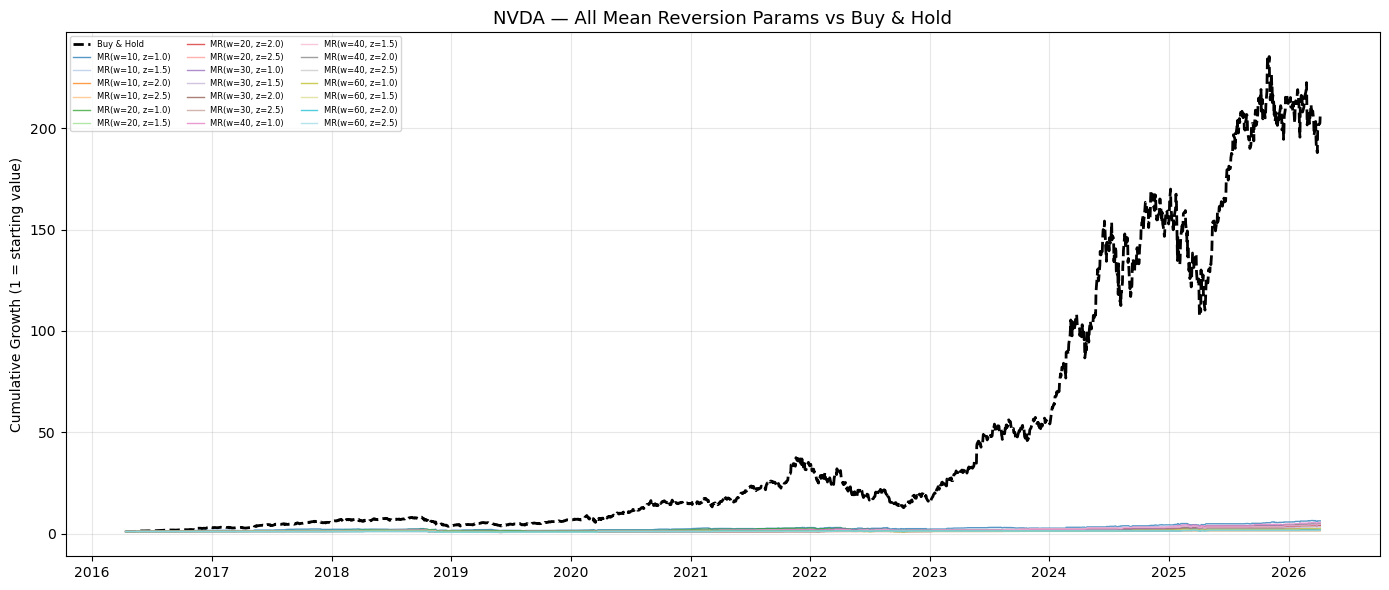

Saved: mr_all_params_NVDA.png



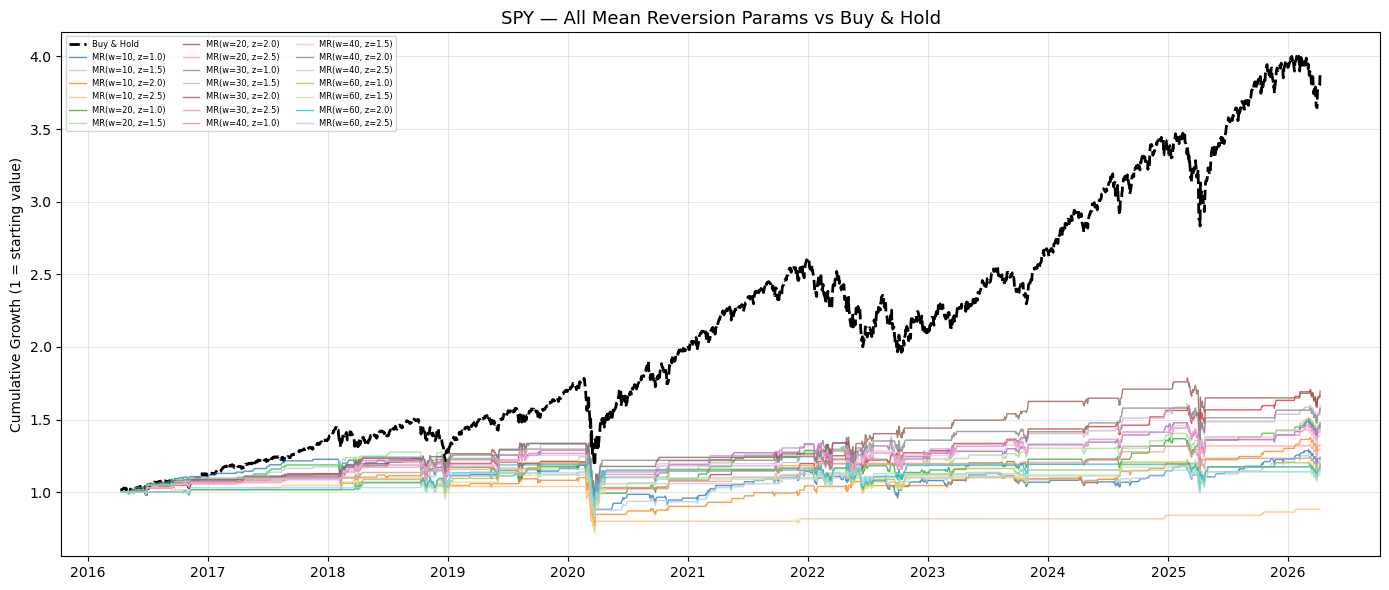

Saved: mr_all_params_SPY.png



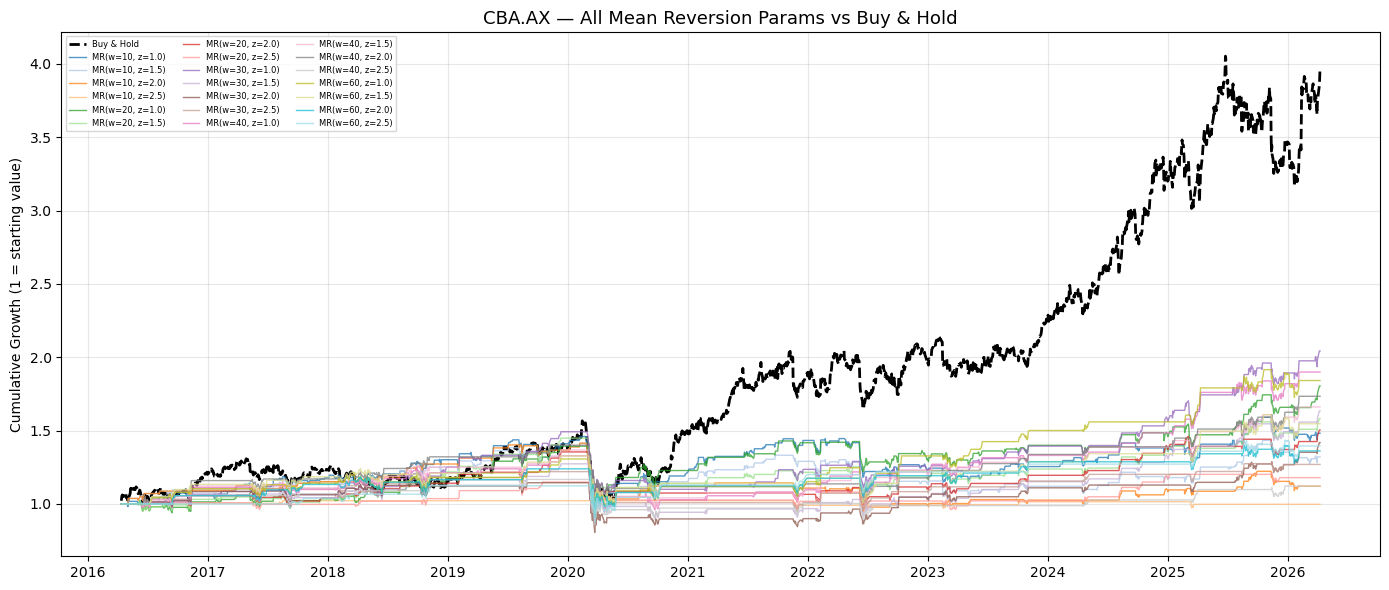

Saved: mr_all_params_CBA.AX.png



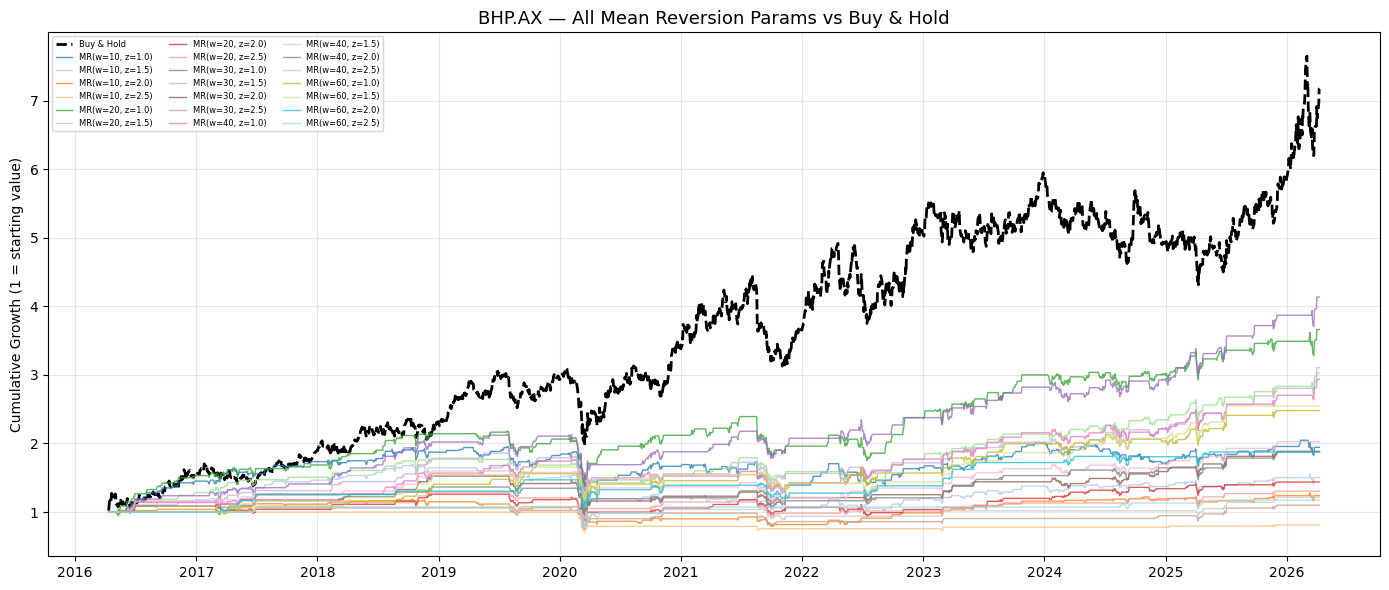

Saved: mr_all_params_BHP.AX.png



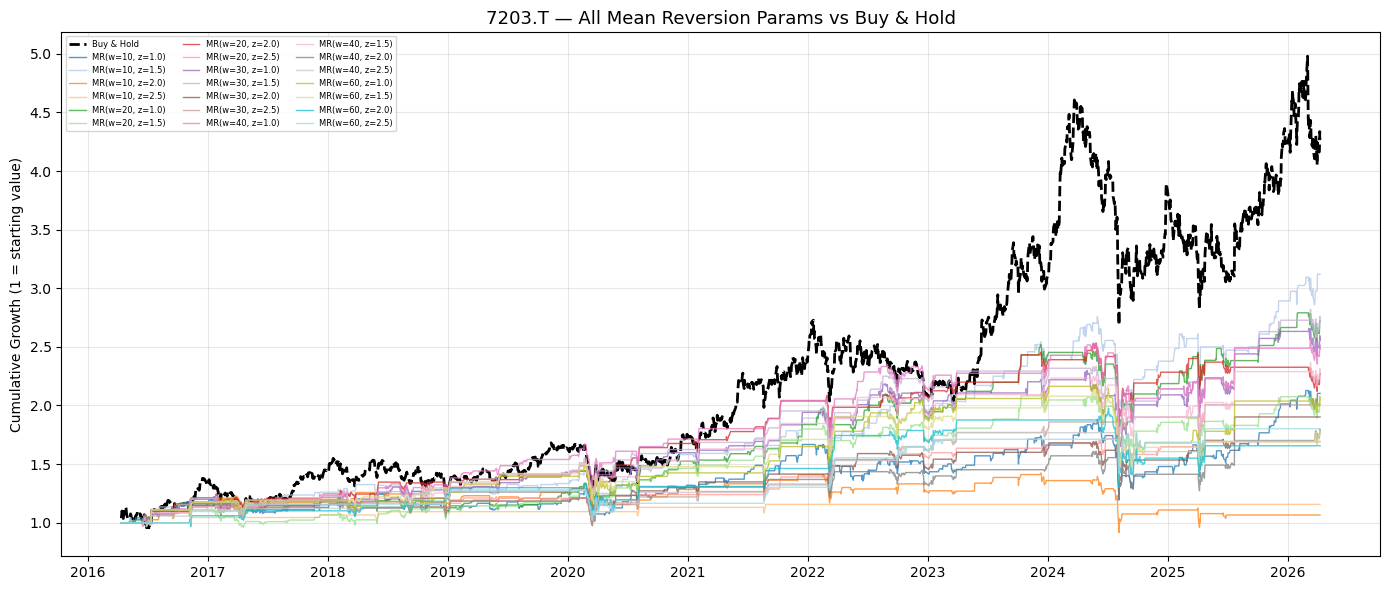

Saved: mr_all_params_7203.T.png



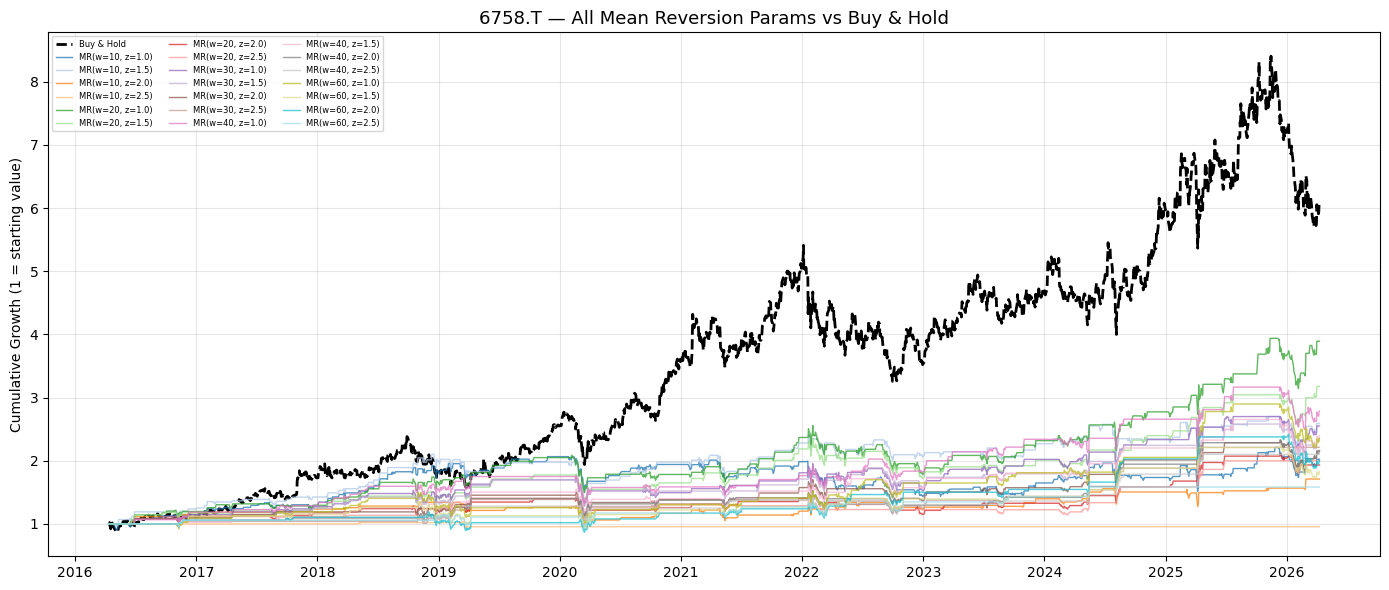

Saved: mr_all_params_6758.T.png



In [6]:
# ── All Mean Reversion params overlaid per stock ───────────────────────────────
# Same idea as MA, RSI, BB, MACD: show every param combo on one chart per stock.
# If many combos cluster together → strategy is ROBUST for that asset.
# If results are wildly spread → results depend heavily on which params you pick
#   → likely overfitting, don't trust those results.
#
# For Mean Reversion, we expect:
#   - 6758.T (Sony) and maybe CBA.AX / BHP.AX to cluster above B&H
#   - NVDA to mostly fall below B&H (it trends, not mean-reverts)
import matplotlib.cm as cm

for stock in stocks:
    sep = '=' * 65
    print(f"\n{sep}")
    print(f"  {stock} — All Mean Reversion Params Compared")
    print(sep)
    print(results_df.loc[stock].to_string())

colors = [cm.tab20(i % 20) for i in range(len(mr_params))]

for stock in stocks:
    fig, ax = plt.subplots(figsize=(14, 6))

    # plot B&H once as black dashed baseline
    w0, t0   = mr_params[0]
    first_df = run_backtest(price_data[stock], w0, t0)
    ax.plot(first_df.index, first_df["cum_market"],
            color="black", linewidth=2, linestyle="--", label="Buy & Hold")

    for (window, threshold), color in zip(mr_params, colors):
        df    = run_backtest(price_data[stock], window, threshold)
        label = f"MR(w={window}, z={threshold})"
        ax.plot(df.index, df["cum_strategy"],
                color=color, linewidth=1.0, alpha=0.75, label=label)

    ax.set_title(f"{stock} — All Mean Reversion Params vs Buy & Hold", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Cumulative Growth (1 = starting value)")
    ax.legend(loc="upper left", fontsize=6, ncol=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"mr_all_params_{stock}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: mr_all_params_{stock}.png\n")



  NVDA: 2580 rows
  SPY: 2580 rows
  CBA.AX: 2597 rows
  BHP.AX: 2597 rows
  7203.T: 2530 rows
  6758.T: 2530 rows

  In-sample  period: 2016-01-01 → 2021-01-01
  Out-of-sample period: 2021-01-01 → 2026-04-09

  STEP 1 — TRAINING (In-Sample: 2016–2020)
  Finding best MR params per stock on training data only...
  NVDA: best in-sample = MR(w=10, z=1.0) (Sharpe: 0.60)
  SPY: best in-sample = MR(w=30, z=2.0) (Sharpe: 0.31)
  CBA.AX: best in-sample = MR(w=20, z=1.0) (Sharpe: 0.31)
  BHP.AX: best in-sample = MR(w=20, z=1.0) (Sharpe: 1.10)
  7203.T: best in-sample = MR(w=60, z=1.5) (Sharpe: 0.88)
  6758.T: best in-sample = MR(w=10, z=1.5) (Sharpe: 1.34)

Full in-sample results:
                        B&H Total Return %  Strat Total Return %  Strat Annual Return %  B&H Sharpe  Strat Sharpe  Strat Max DD %
Ticker MR Params                                                                                                                 
NVDA   MR(w=10, z=1.0)             1548.76                

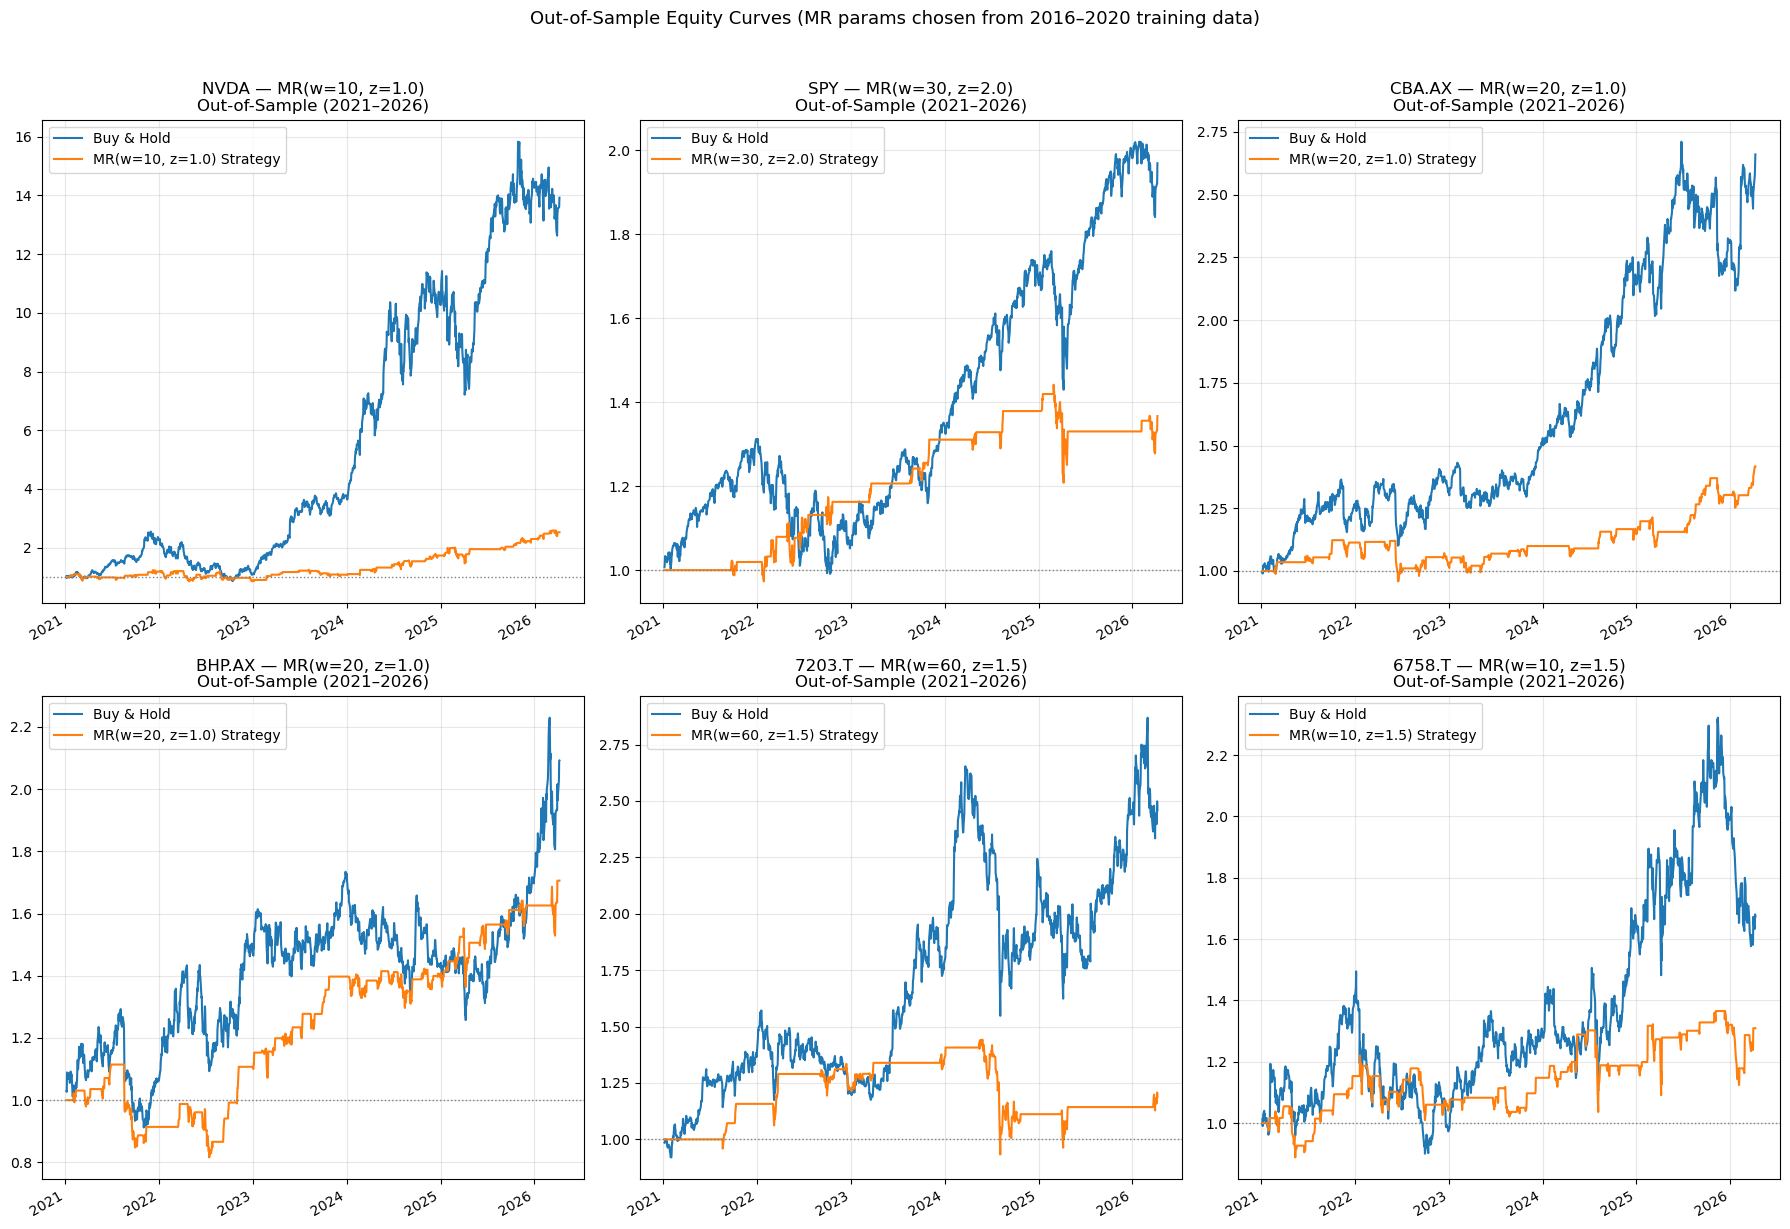


Chart saved as mr_out_of_sample_equity_curves.png


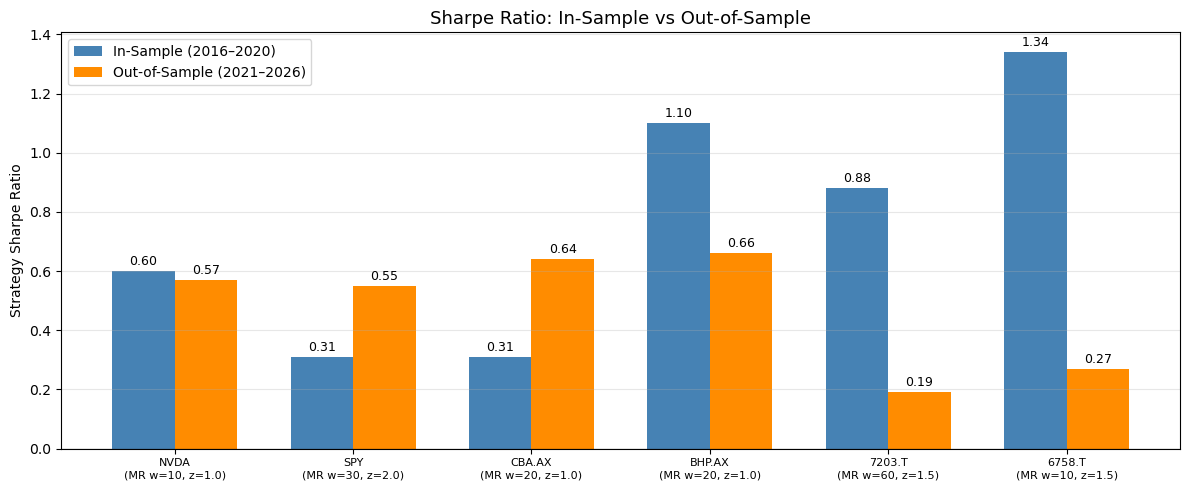

Chart saved as mr_sharpe_in_vs_out.png


In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import re

# ── Configuration ──────────────────────────────────────────────────────────────
FULL_START = dt.datetime(2016, 1, 1)
SPLIT_DATE = dt.datetime(2021, 1, 1)   # train = before this, test = after this
FULL_END   = dt.datetime.now()

stocks     = ["NVDA", "SPY", "CBA.AX", "BHP.AX", "7203.T", "6758.T"]
windows    = [10, 20, 30, 40, 60]
thresholds = [1.0, 1.5, 2.0, 2.5]
mr_params  = [(w, t) for w in windows for t in thresholds]

PERIODS_PER_YEAR = 252


# ── Helpers (same as Cell 4) ───────────────────────────────────────────────────
def compute_zscore(price_series, window):
    rolling_mean = price_series.rolling(window=window).mean()
    rolling_std  = price_series.rolling(window=window).std()
    return (price_series - rolling_mean) / rolling_std

def run_backtest(price_series, window, threshold):
    df = pd.DataFrame({"price": price_series})
    df["zscore"] = compute_zscore(df["price"], window)
    signal   = np.zeros(len(df))
    in_trade = False
    for i in range(len(df)):
        z = df["zscore"].iloc[i]
        if np.isnan(z):
            signal[i] = 0
        elif not in_trade and z < -threshold:
            in_trade  = True
            signal[i] = 1
        elif in_trade and z >= 0:
            in_trade  = False
            signal[i] = 0
        else:
            signal[i] = 1 if in_trade else 0
    df["signal_raw"] = signal
    df["position"]   = df["signal_raw"].shift(1)
    df["log_returns"]          = np.log(df["price"] / df["price"].shift(1))
    df["strategy_log_returns"] = df["position"] * df["log_returns"]
    df["cum_market"]   = np.exp(df["log_returns"].cumsum())
    df["cum_strategy"] = np.exp(df["strategy_log_returns"].cumsum())
    return df

def max_drawdown(cum_series):
    running_max = cum_series.cummax()
    return ((cum_series - running_max) / running_max).min()

def get_metrics(df):
    market_lr   = df["log_returns"].dropna()
    strategy_lr = df["strategy_log_returns"].dropna()
    total_mkt    = df["cum_market"].dropna().iloc[-1]   - 1
    total_strat  = df["cum_strategy"].dropna().iloc[-1] - 1
    ann_mkt      = np.exp(market_lr.mean()   * PERIODS_PER_YEAR) - 1
    ann_strat    = np.exp(strategy_lr.mean() * PERIODS_PER_YEAR) - 1
    vol_mkt      = market_lr.std()   * np.sqrt(PERIODS_PER_YEAR)
    vol_strat    = strategy_lr.std() * np.sqrt(PERIODS_PER_YEAR)
    sharpe_mkt   = ann_mkt   / vol_mkt   if vol_mkt   != 0 else np.nan
    sharpe_strat = ann_strat / vol_strat if vol_strat != 0 else np.nan
    mdd_strat    = max_drawdown(df["cum_strategy"].dropna())
    return {
        "B&H Total Return %":    round(total_mkt   * 100, 2),
        "Strat Total Return %":  round(total_strat * 100, 2),
        "Strat Annual Return %": round(ann_strat   * 100, 2),
        "B&H Sharpe":            round(sharpe_mkt,   2),
        "Strat Sharpe":          round(sharpe_strat, 2),
        "Strat Max DD %":        round(mdd_strat   * 100, 2),
    }


# ── Step 1: Download full price data ──────────────────────────────────────────
print("Downloading data...\n")
price_data = {}
for stock in stocks:
    raw = yf.download(stock, start=FULL_START, end=FULL_END,
                      auto_adjust=True, progress=False)
    price_data[stock] = raw["Close"].squeeze()
    print(f"  {stock}: {len(raw)} rows")


# ── Step 2: Split into in-sample and out-of-sample ────────────────────────────
in_sample  = {s: price_data[s][price_data[s].index < SPLIT_DATE]  for s in stocks}
out_sample = {s: price_data[s][price_data[s].index >= SPLIT_DATE] for s in stocks}

print(f"\n  In-sample  period: {FULL_START.date()} → {SPLIT_DATE.date()}")
print(f"  Out-of-sample period: {SPLIT_DATE.date()} → {FULL_END.date()}\n")


# ── Step 3: Find best params per stock using IN-SAMPLE data ONLY ───────────────
# CRITICAL CONCEPT: We pick params using ONLY 2016-2020 data.
# We never let the model see 2021-2026 during training.
# If we picked params using all data, the results would look great but be fake —
# the strategy would have "seen the future" during optimisation.
# This is called look-ahead bias and it's one of the most common mistakes in quant.
print("=" * 70)
print("  STEP 1 — TRAINING (In-Sample: 2016–2020)")
print("  Finding best MR params per stock on training data only...")
print("=" * 70)

best_params       = {}
in_sample_results = []

for stock in stocks:
    best_sharpe = -999
    best_p      = None
    for window, threshold in mr_params:
        df      = run_backtest(in_sample[stock], window, threshold)
        metrics = get_metrics(df)
        label   = f"MR(w={window}, z={threshold})"
        metrics["Ticker"]    = stock
        metrics["MR Params"] = label
        in_sample_results.append(metrics)
        if metrics["Strat Sharpe"] > best_sharpe:
            best_sharpe = metrics["Strat Sharpe"]
            best_p      = (window, threshold)
    best_params[stock] = best_p
    w, t = best_p
    print(f"  {stock}: best in-sample = MR(w={w}, z={t}) "
          f"(Sharpe: {best_sharpe:.2f})")

in_sample_df = pd.DataFrame(in_sample_results).set_index(["Ticker", "MR Params"])
print("\nFull in-sample results:")
print(in_sample_df.to_string())


# ── Step 4: Apply chosen params to OUT-OF-SAMPLE data ─────────────────────────
print("\n" + "=" * 70)
print("  STEP 2 — TESTING (Out-of-Sample: 2021–2026)")
print("  Applying params chosen from training data to unseen data...")
print("=" * 70)

oos_results = []
oos_data    = {}

for stock in stocks:
    window, threshold = best_params[stock]
    df      = run_backtest(out_sample[stock], window, threshold)
    metrics = get_metrics(df)
    label   = f"MR(w={window}, z={threshold})"
    metrics["Ticker"]    = stock
    metrics["MR Params"] = label
    oos_results.append(metrics)
    oos_data[stock] = df
    print(f"\n  {stock} — {label} on out-of-sample data:")
    for k, v in metrics.items():
        if k not in ["Ticker", "MR Params"]:
            print(f"    {k}: {v}")

oos_df = pd.DataFrame(oos_results).set_index("Ticker")


# ── Step 5: Side-by-side comparison table ─────────────────────────────────────
print("\n" + "=" * 70)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 70)

rows = []
for stock in stocks:
    w, t   = best_params[stock]
    label  = f"MR(w={w}, z={t})"
    in_s   = in_sample_df.loc[(stock, label)]
    out_s  = oos_df.loc[stock]
    rows.append({
        "Ticker":              stock,
        "Best Params":         label,
        "IN Strat Return %":   in_s["Strat Total Return %"],
        "OUT Strat Return %":  out_s["Strat Total Return %"],
        "IN B&H Return %":     in_s["B&H Total Return %"],
        "OUT B&H Return %":    out_s["B&H Total Return %"],
        "IN Sharpe":           in_s["Strat Sharpe"],
        "OUT Sharpe":          out_s["Strat Sharpe"],
        "IN Max DD %":         in_s["Strat Max DD %"],
        "OUT Max DD %":        out_s["Strat Max DD %"],
    })

comparison = pd.DataFrame(rows).set_index("Ticker")
print(comparison.to_string())

print("\n  VERDICT:")
for stock in stocks:
    in_sharpe  = comparison.loc[stock, "IN Sharpe"]
    out_sharpe = comparison.loc[stock, "OUT Sharpe"]
    drop       = ((out_sharpe - in_sharpe) / abs(in_sharpe)) * 100 if in_sharpe != 0 else float("nan")
    out_ret    = comparison.loc[stock, "OUT Strat Return %"]
    beats_bah  = out_ret > comparison.loc[stock, "OUT B&H Return %"]
    print(f"  {stock}: Sharpe {in_sharpe:.2f} -> {out_sharpe:.2f} "
          f"({drop:+.1f}%)  |  Beats B&H out-of-sample: {beats_bah}")


# ── Step 6: Out-of-sample equity curves ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, stock in enumerate(stocks):
    ax               = axes[i]
    window, threshold = best_params[stock]
    df               = oos_data[stock]
    label            = f"MR(w={window}, z={threshold})"

    df[["cum_market", "cum_strategy"]].plot(ax=ax)
    ax.set_title(f"{stock} — {label}\nOut-of-Sample (2021–2026)", fontsize=12)
    ax.legend(["Buy & Hold", f"{label} Strategy"])
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color="gray", linestyle=":", linewidth=1)

plt.suptitle("Out-of-Sample Equity Curves (MR params chosen from 2016–2020 training data)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("mr_out_of_sample_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as mr_out_of_sample_equity_curves.png")


# ── Step 7: In-sample vs Out-of-sample Sharpe bar chart ──────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

x      = np.arange(len(stocks))
width  = 0.35
in_sh  = [comparison.loc[s, "IN Sharpe"]  for s in stocks]
out_sh = [comparison.loc[s, "OUT Sharpe"] for s in stocks]

bars1 = ax2.bar(x - width/2, in_sh,  width, label="In-Sample (2016–2020)",     color="steelblue")
bars2 = ax2.bar(x + width/2, out_sh, width, label="Out-of-Sample (2021–2026)", color="darkorange")

param_labels = [f"{s}\n(MR w={best_params[s][0]}, z={best_params[s][1]})" for s in stocks]
ax2.set_xticks(x)
ax2.set_xticklabels(param_labels, fontsize=8)
ax2.set_ylabel("Strategy Sharpe Ratio")
ax2.set_title("Sharpe Ratio: In-Sample vs Out-of-Sample", fontsize=13)
ax2.legend()
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.grid(True, alpha=0.3, axis="y")

for bar in bars1 + bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("mr_sharpe_in_vs_out.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as mr_sharpe_in_vs_out.png")
